In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'D:\Previous Laptop Backup\Preperation\2026\05 Project\Modeling\application_record.csv')

display(df.head(5))

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,DECISION
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2,Not Approved
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2,Not Approved
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1,Not Approved
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1,Not Approved
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2,Not Approved


Data Exploration and Cleaning

In [174]:
display(df.describe())
print("="*100)
display(df.info())
print("="*100)
display(df['DECISION'].value_counts())

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,9.997000e+03,9997.000000,9.997000e+03,9997.000000,9997.000000,9997.0,9997.000000,9997.000000,9997.000000,9997.000000
mean,5.076313e+06,0.423427,1.814796e+05,-15985.967890,61541.303491,1.0,0.218866,0.288487,0.087826,2.183455
std,4.087912e+04,0.767006,9.950810e+04,4244.031608,139486.833251,0.0,0.413498,0.453081,0.283056,0.933436
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.036980e+06,0.000000,1.125000e+05,-19538.000000,-2992.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,5.069530e+06,0.000000,1.575000e+05,-15615.000000,-1373.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,5.113028e+06,1.000000,2.250000e+05,-12423.000000,-339.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,5.150479e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


<class 'pandas.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9997 non-null   int64  
 1   CODE_GENDER          9997 non-null   str    
 2   FLAG_OWN_CAR         9997 non-null   str    
 3   FLAG_OWN_REALTY      9997 non-null   str    
 4   CNT_CHILDREN         9997 non-null   int64  
 5   AMT_INCOME_TOTAL     9997 non-null   float64
 6   NAME_INCOME_TYPE     9997 non-null   str    
 7   NAME_EDUCATION_TYPE  9997 non-null   str    
 8   NAME_FAMILY_STATUS   9997 non-null   str    
 9   NAME_HOUSING_TYPE    9997 non-null   str    
 10  DAYS_BIRTH           9997 non-null   int64  
 11  DAYS_EMPLOYED        9997 non-null   int64  
 12  FLAG_MOBIL           9997 non-null   int64  
 13  FLAG_WORK_PHONE      9997 non-null   int64  
 14  FLAG_PHONE           9997 non-null   int64  
 15  FLAG_EMAIL           9997 non-null   int64  
 16 

None

DECISION
Not Approved    9555
Approved         442
Name: count, dtype: int64

In [175]:
# OCCUPATION_TYPE has null records which will be replaced by Unknown
df.fillna("Unknown",inplace=True)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,DECISION
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2,Not Approved
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2,Not Approved
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1,Not Approved
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,Unknown,1,Not Approved
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2,Not Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2,Approved
9993,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2,Approved
9994,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2,Approved
9995,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2,Approved


In [176]:
# According to the BRs, +ve days employed refers to unemployed
# So make the days employed as 0 where ever it is +ve
df.loc[df['DAYS_EMPLOYED']> 0,'DAYS_EMPLOYED'] = 0

In [177]:
# Create years employed variable and drop days employed. Same for days birth create age variable
df['YEARS_EMPLOYED'] = -1*df['DAYS_EMPLOYED']/365
df.drop(columns='DAYS_EMPLOYED', inplace=True)

df['AGE'] = -1*df['DAYS_BIRTH']/365
df.drop(columns='DAYS_BIRTH', inplace=True)

In [178]:
# Drop flag mobil because min and max value 1 and all values as 1. So it is not useful for model building.

display(f"Columns before dropping :{df.columns}")
df.drop(columns=['FLAG_MOBIL'], inplace=True)
display(f"Columns after dropping :{df.columns}")

"Columns before dropping :Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',\n       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',\n       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL',\n       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',\n       'CNT_FAM_MEMBERS', 'DECISION', 'YEARS_EMPLOYED', 'AGE'],\n      dtype='str')"

"Columns after dropping :Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',\n       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',\n       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',\n       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',\n       'DECISION', 'YEARS_EMPLOYED', 'AGE'],\n      dtype='str')"

Exploratory Data Analysis

In [179]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,DECISION,YEARS_EMPLOYED,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,2,Not Approved,12.443836,32.890411
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,2,Not Approved,3.106849,58.832877
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1,Not Approved,8.358904,52.356164
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,Unknown,1,Not Approved,0.000000,61.545205
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,Accountants,2,Not Approved,2.106849,46.224658


"Categorical columns : Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',\n       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',\n       'OCCUPATION_TYPE', 'DECISION'],\n      dtype='str')"

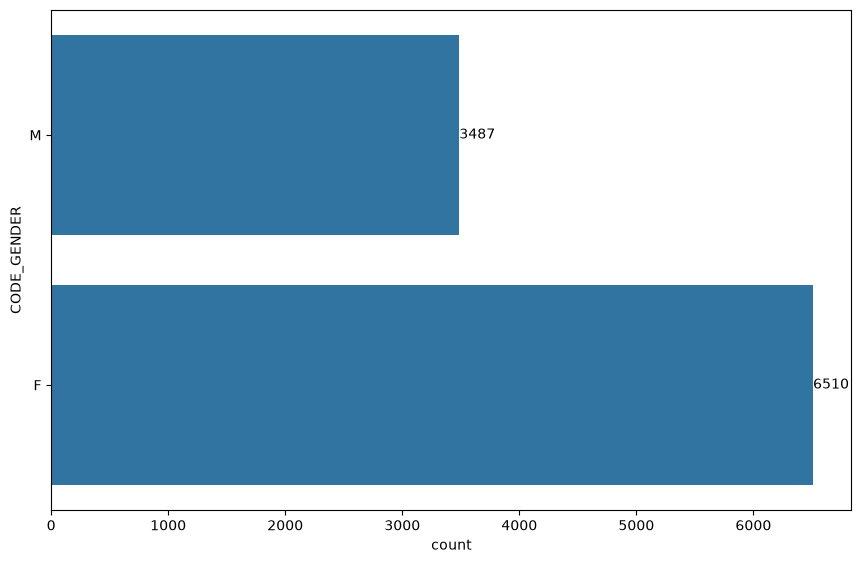

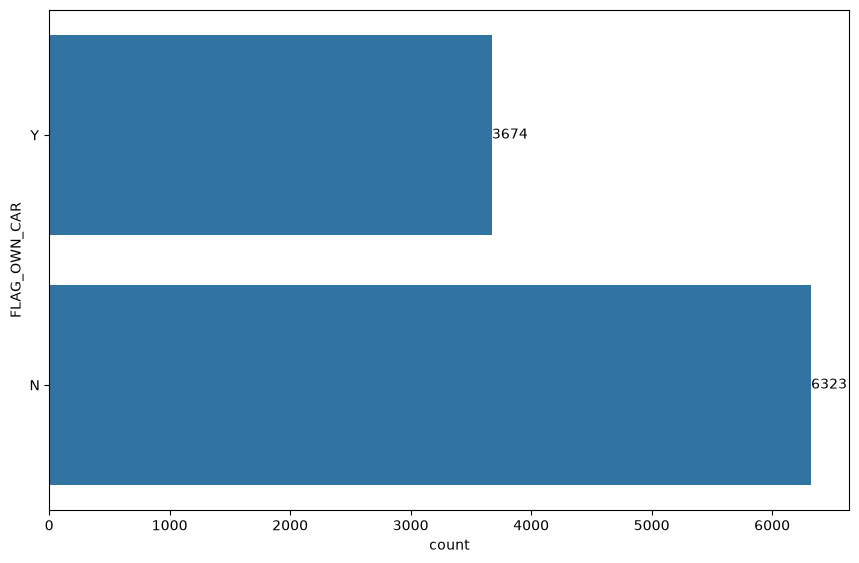

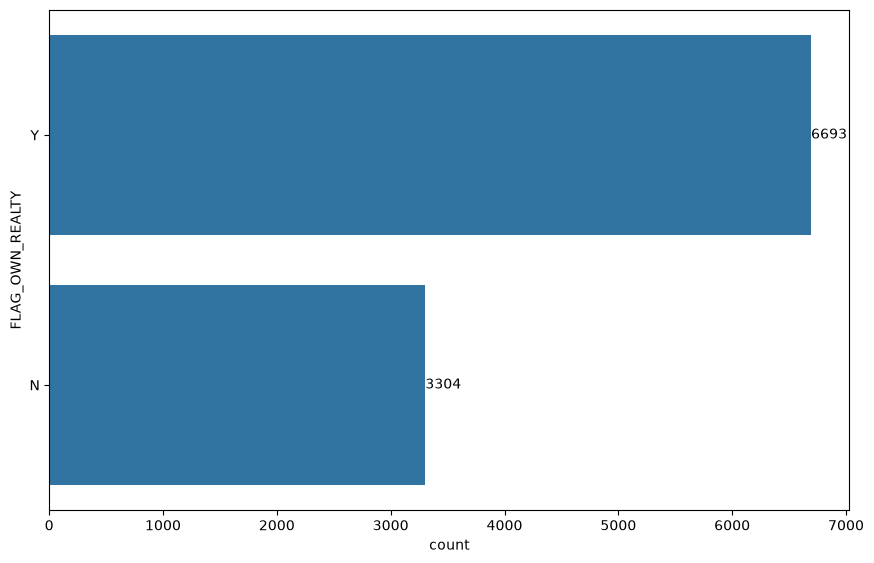

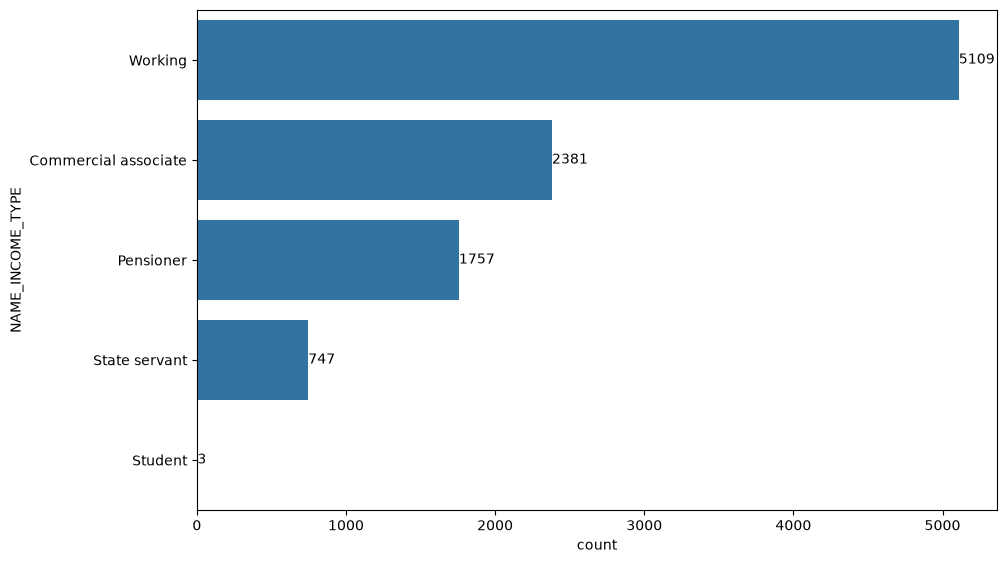

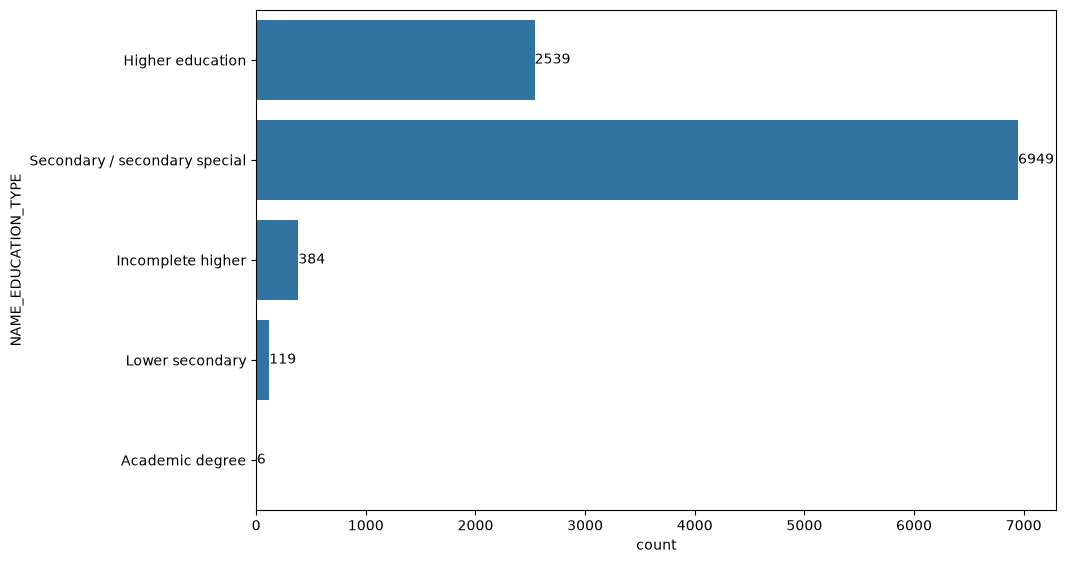

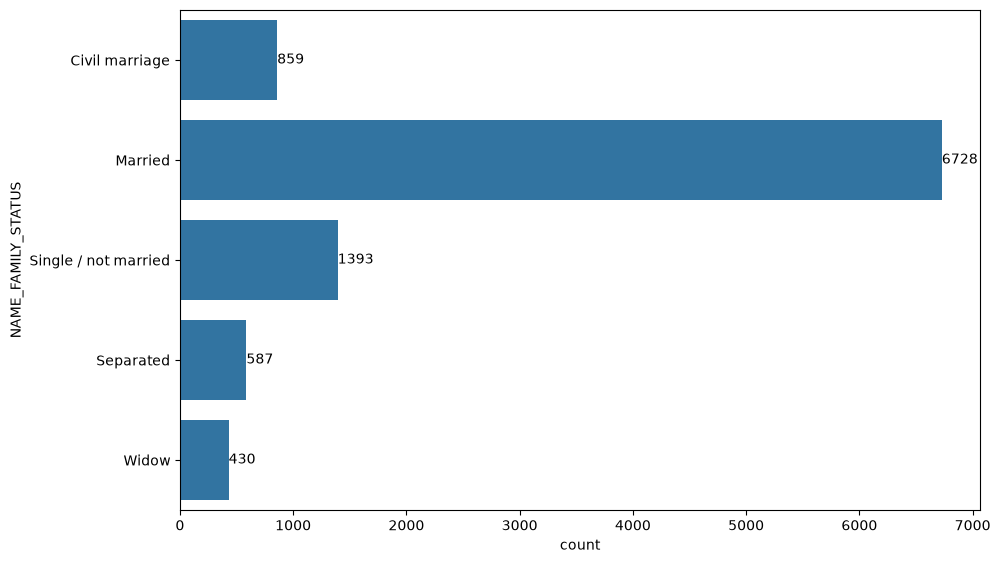

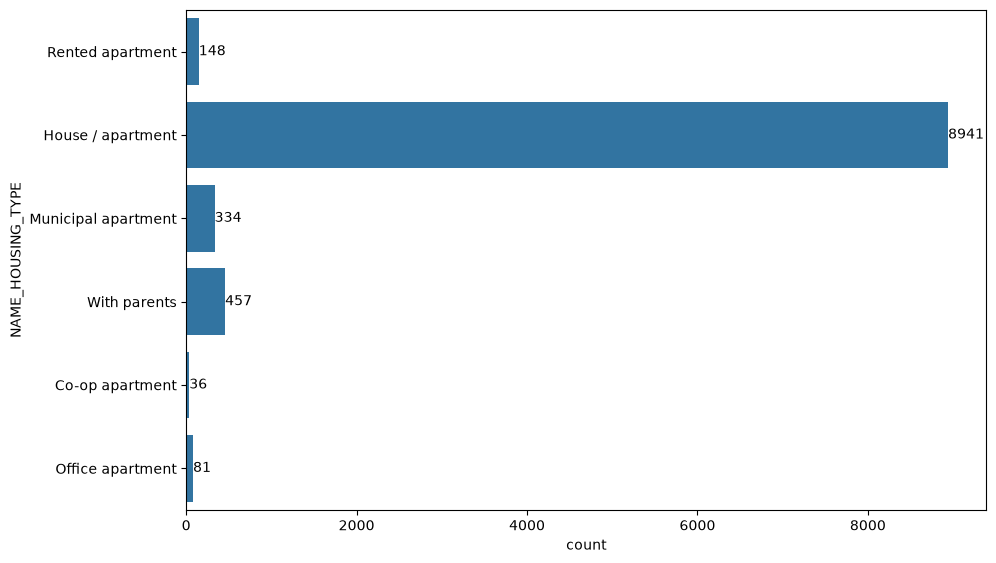

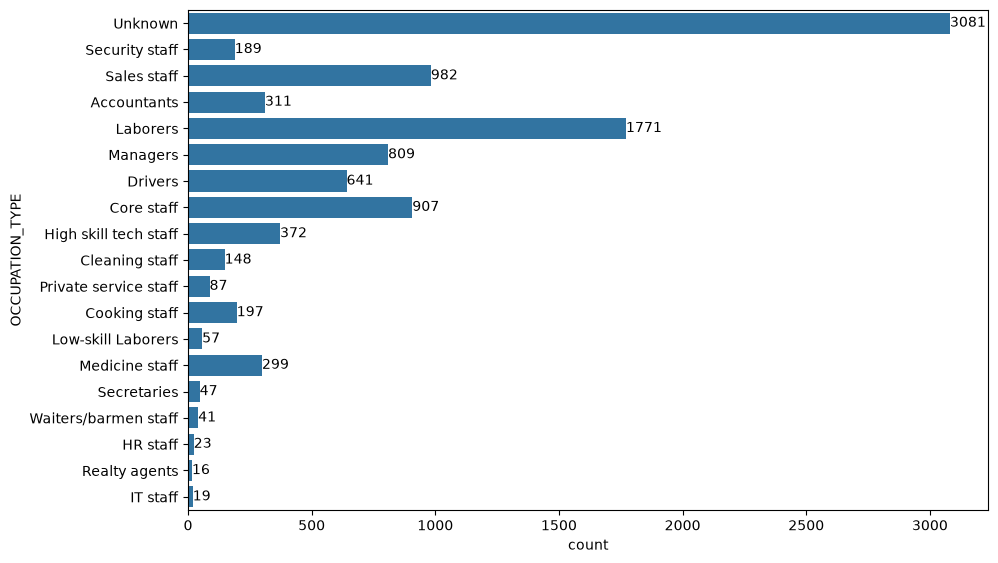

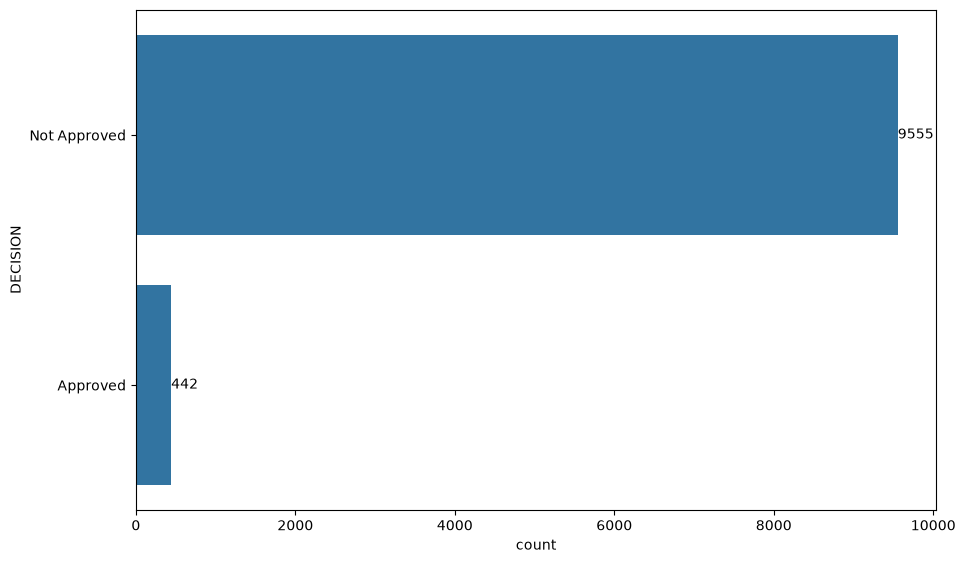

In [180]:
df_categorical = df.select_dtypes(include=['object','str']).columns
display(f"Categorical columns : {df_categorical}")
n = 1

for col in df_categorical :
    fig = plt.figure(figsize=(8, 5))
    ax1 = fig.add_axes([0.1, 0.1, 1, 1])
    sns.countplot(y=col, data=df, ax=ax1)
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%d')
    # break

# fig = plt.figure()

# # First axes
# ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# sns.countplot(x='CODE_GENDER', data=df, ax=ax1)

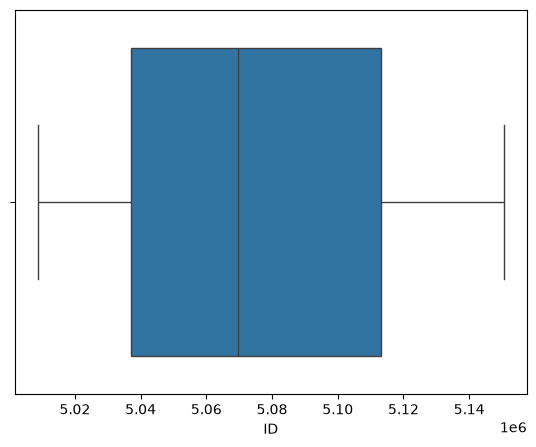

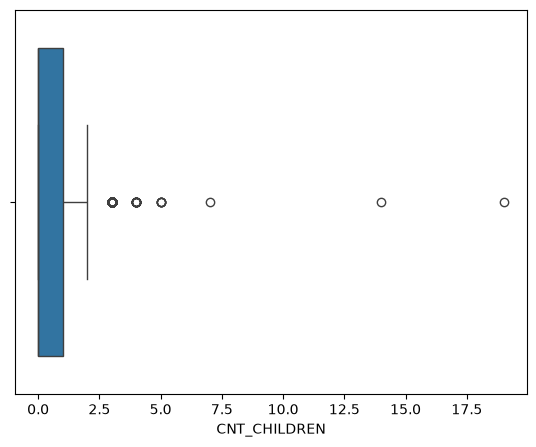

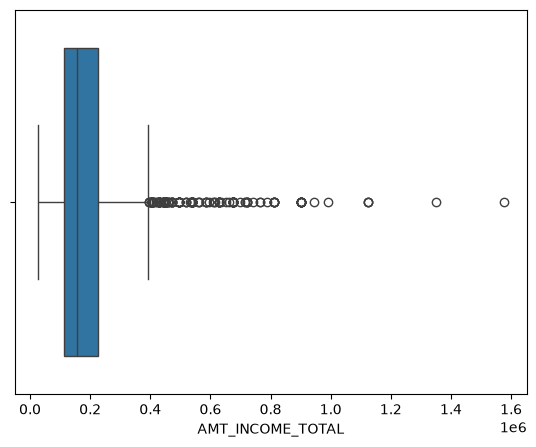

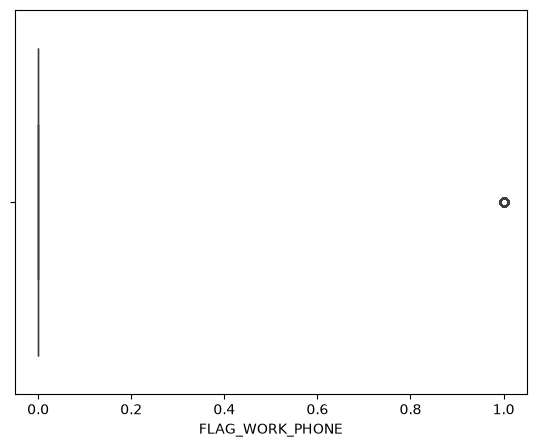

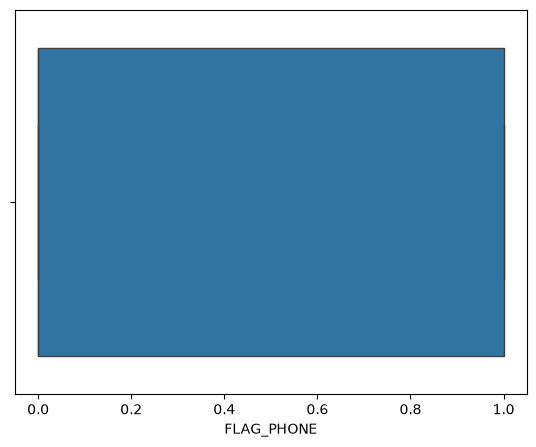

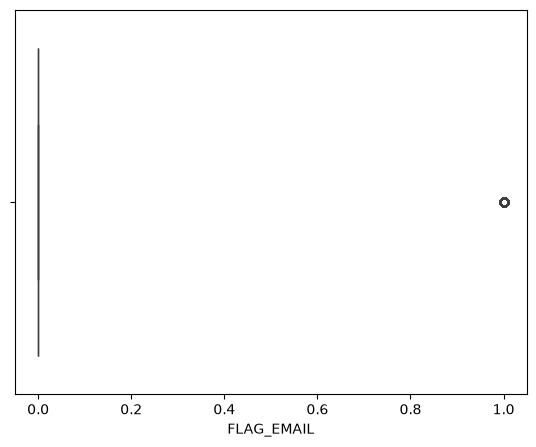

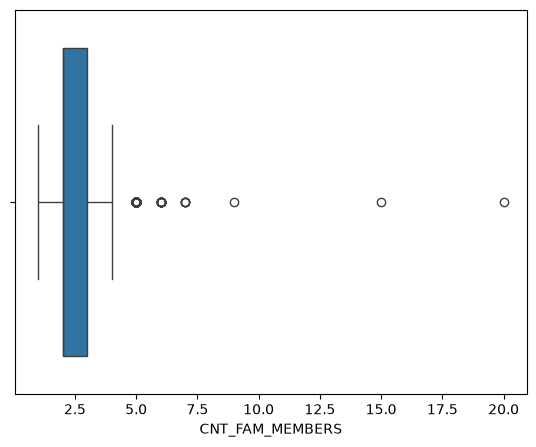

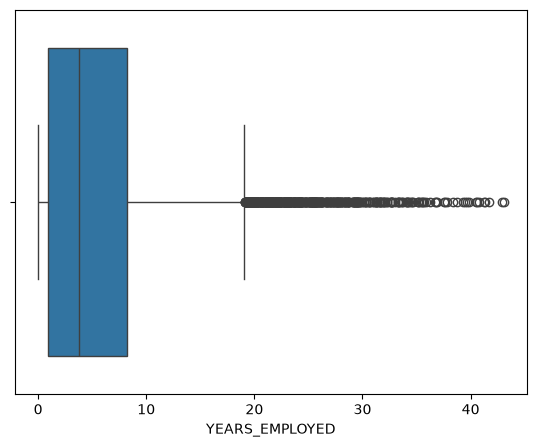

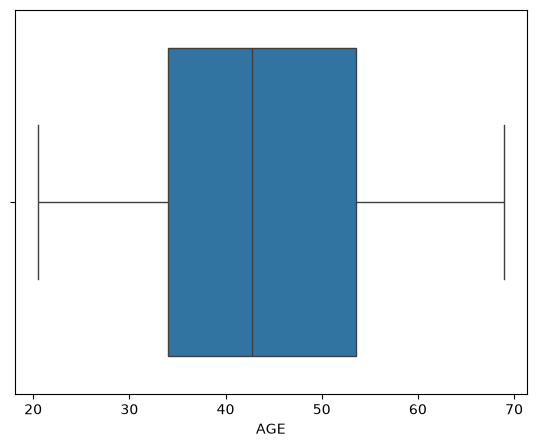

In [181]:
df_numerical = df.select_dtypes(include=['int','float']).columns
for col in df_numerical :
    fig = plt.figure()
    fig.add_axes([0.1, 0.1, 0.8, 0.8])
    sns.boxplot(x=col, data=df)

In [182]:
# Count of childen > 7 to be removed because it is not possible to have more than 7 children. So we will remove those records.

df = df[df['CNT_CHILDREN'] <= 7]

In [183]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'DECISION', 'YEARS_EMPLOYED', 'AGE'],
      dtype='str')

In [184]:
# df['ALL_DEVICE_FLAG'] = df['FLAG_WORK_PHONE']*df['FLAG_PHONE']*df['FLAG_EMAIL']

# df.loc[(df['FLAG_OWN_CAR']=='Y')*(df['FLAG_OWN_REALTY']=='Y'),'ALL_OWNER_FLAG']='Y'
# df.loc[df['ALL_OWNER_FLAG']!='Y','ALL_OWNER_FLAG']='N'
# df_pivot = df.pivot_table(index='ALL_OWNER_FLAG',columns='DECISION',aggfunc='count',values='AGE')
# df_pivot
# df_numerical = df.select_dtypes(include=['int','float']).columns
# df.dtypes

<Axes: >

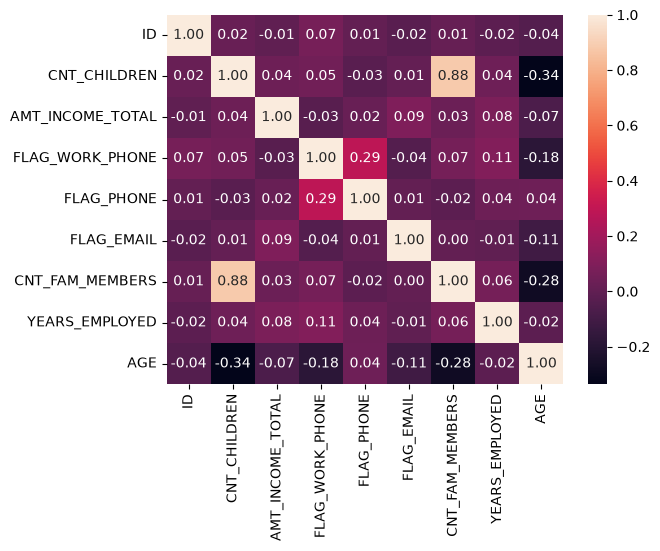

In [185]:
# Count of family members and count of childern are highly correlated.
# So we will drop one of them. For this we will check the coverge of these two columns.
sns.heatmap(df[df_numerical].corr(), annot=True, fmt=".2f")

In [186]:
display(df['CNT_CHILDREN'].value_counts())
display("="*100)
display(df['CNT_FAM_MEMBERS'].value_counts())

CNT_CHILDREN
0    7019
1    1942
2     877
3     132
4      19
5       5
7       1
Name: count, dtype: int64

'===================================================================================================='

CNT_FAM_MEMBERS
2    5333
1    2005
3    1684
4     826
5     123
6      19
7       4
9       1
Name: count, dtype: int64

In [187]:
# Since count of family members have no zero value we can exclude count of children column and keep count of family members column.
df.drop(columns=['CNT_CHILDREN'], inplace=True)
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'DECISION', 'YEARS_EMPLOYED', 'AGE'],
      dtype='str')

In [188]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [189]:
X = df.drop(columns=['DECISION','ID'])
y = df['DECISION']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (7996, 15)
Testing Set  : (1999, 15)


In [190]:
# Get categorical column names
categorical_cols = X.select_dtypes(include=['object','str']).columns.tolist()

# Calculate weights inversely proportional to class frequency
approved_weight = len(y_train) / (2 * sum(y_train == "Approved"))
not_approved_weight = len(y_train) / (2 * sum(y_train == "Not Approved"))

# Define model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    cat_features=categorical_cols,   # pass names, not DataFrame
    class_weights=[approved_weight, not_approved_weight]  # order matches class order
)

# Train
model.fit(X_train, y_train)

print(f"Weights are {approved_weight} and {not_approved_weight}")

Weights are 11.293785310734464 and 0.5231614760533891


In [191]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

# Predictions
y_test_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Convert to DataFrame with labels
labels = model.classes_
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion Matrix (Counts):")
print(cm_df)

# Confusion matrix with percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percent_df = pd.DataFrame(np.round(cm_percent, 2), index=labels, columns=labels)

print("\nConfusion Matrix (Percentages %):")
print(cm_percent_df)

# Classification report for precision/recall/F1
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Confusion Matrix (Counts):
              Approved  Not Approved
Approved            26            62
Not Approved       467          1444

Confusion Matrix (Percentages %):
              Approved  Not Approved
Approved         29.55         70.45
Not Approved     24.44         75.56

Classification Report:
              precision    recall  f1-score   support

    Approved       0.05      0.30      0.09        88
Not Approved       0.96      0.76      0.85      1911

    accuracy                           0.74      1999
   macro avg       0.51      0.53      0.47      1999
weighted avg       0.92      0.74      0.81      1999

